# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model |Perplexity |
| Used for | to help me understand the Keras model components, dropout, early stopping|
| Verified how |I verified the notebook by running all cells from start to finish, checking that the model summary and       architecture diagram were produced 
| Not used for |completing the assignment |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks

# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [2]:
max_features = 10000
max_len = 500

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# Pad sequences
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len)
x_test  = keras.utils.pad_sequences(x_test,  maxlen=max_len)

# Validation split – first 10 000 for val
x_val = x_train[:10000]
y_val = y_train[:10000]
x_train = x_train[10000:]
y_train = y_train[10000:]

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)

train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [3]:
def build_baseline():
    model = keras.Sequential([
        layers.Embedding(max_features, 32),          # input_length is deprecated
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline = build_baseline()

# Build the model so summary shows real shapes & parameter counts
baseline.build(input_shape=(None, max_len))
baseline.summary()

hist_baseline = baseline.fit(
    x_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1,
)

baseline_val_acc = max(hist_baseline.history["val_accuracy"])
print(f"Baseline best val accuracy (Moodle a3_baseline_val): {baseline_val_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,089 (1.22 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5431 - loss: 0.6915 - val_accuracy: 0.6553 - val_loss: 0.6880
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6087 - loss: 0.6808 - val_accuracy: 0.5492 - val_loss: 0.6802
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6595 - loss: 0.6550 - val_accuracy: 0.6812 - val_loss: 0.6363
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7209 - loss: 0.6082 - val_accuracy: 0.7606 - val_loss: 0.5837
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7819 - loss: 0.5494 - val_accuracy: 0.7970 - val_loss: 0.5259
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7639 - loss: 0.5081 - val_accuracy: 0.6513 - val_loss: 0.5825
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7853 - loss: 0.4739 - val_accuracy: 0.7576 - val_loss: 0.4774
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8351 - loss: 0.4237 - val_accuracy: 0.8162 - val_loss

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963,269 (3.67 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 642,180 (2.45 MB)

Wrote imdb_model.png — commit this image to your GitHub repo


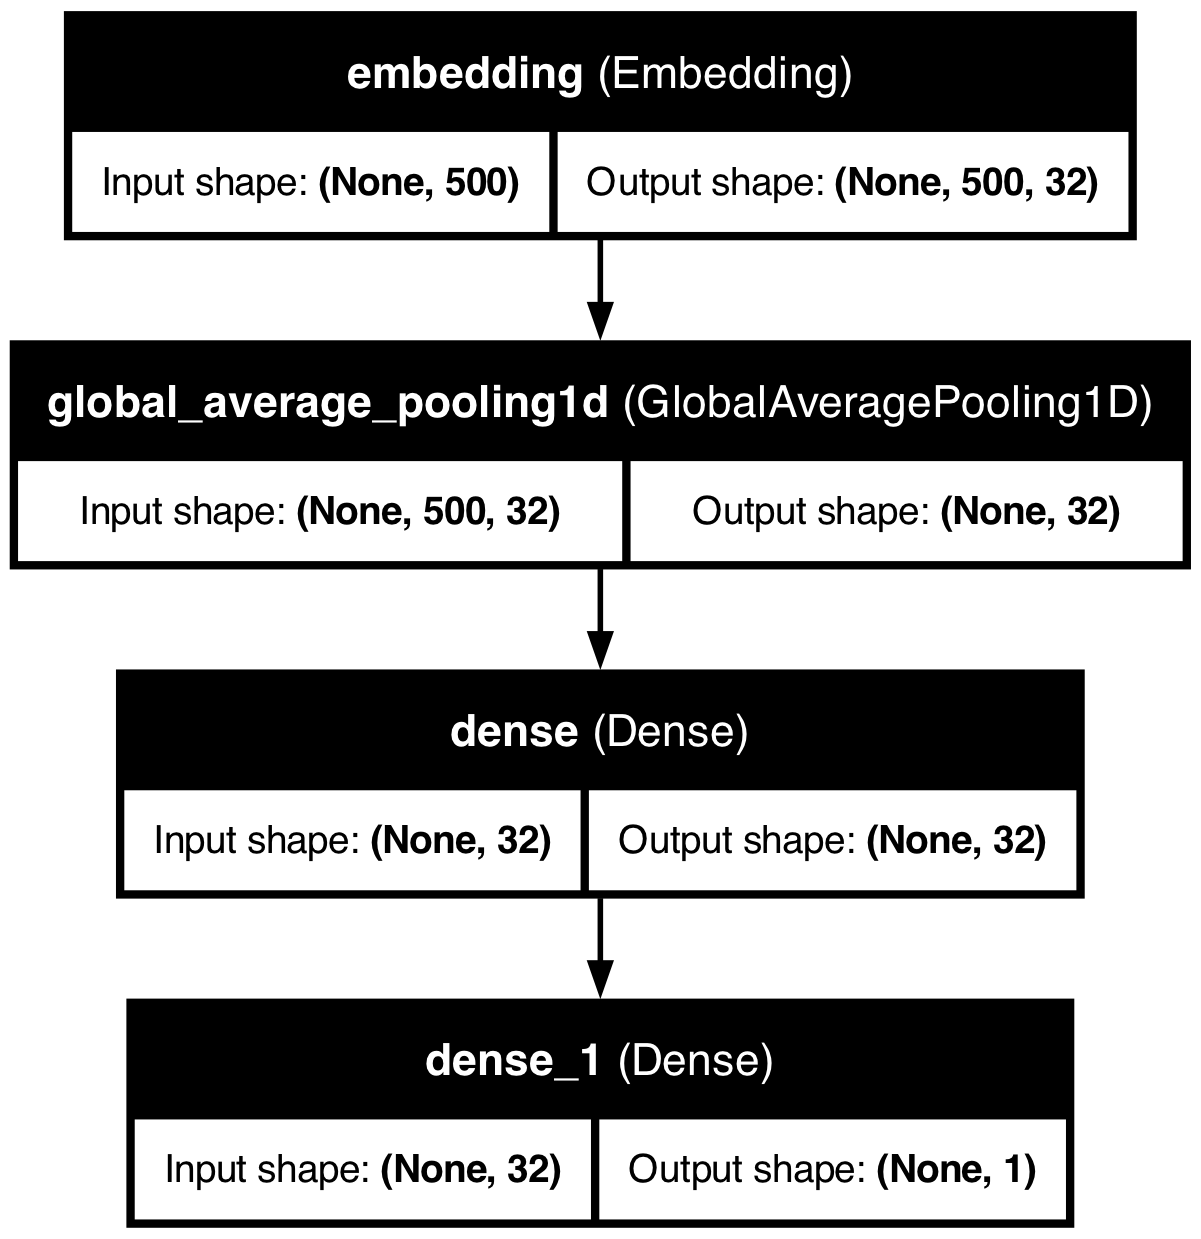

In [4]:
# TODO: print architecture summary

    # Build the model with the expected input shape
baseline.build(input_shape=(None, max_len))

# Print model architecture
baseline.summary()

DIAGRAM_FILE = "imdb_model.png"

try:
    keras.utils.plot_model(
        baseline,
        to_file=DIAGRAM_FILE,
        show_shapes=True,
        show_layer_names=True
    )

    print(f"Wrote {DIAGRAM_FILE} — commit this image to your GitHub repo")

    from IPython.display import Image, display
    display(Image(filename=DIAGRAM_FILE))

except Exception as e:
    print("plot_model failed:", e)

## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [5]:
USE_L2 = False
USE_DROPOUT = True
USE_EARLY_STOP = True

reg_model = keras.Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(max_features, 32),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
])

if USE_DROPOUT:
    reg_model.add(layers.Dropout(0.5))

reg_model.add(layers.Dense(1, activation="sigmoid"))

reg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Build so summary is useful
reg_model.build(input_shape=(None, max_len))
reg_model.summary()

cb = []
if USE_EARLY_STOP:
    cb.append(callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ))

hist_reg = reg_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=cb,
    verbose=1,
)

best_val_acc = max(hist_reg.history["val_accuracy"])
techniques = []
if USE_L2:          techniques.append("L2")
if USE_DROPOUT:     techniques.append("dropout")
if USE_EARLY_STOP:  techniques.append("early stopping")

print(f"Techniques (Moodle a3_techniques): {', '.join(techniques)}")
print(f"Best val accuracy (Moodle a3_best_val): {best_val_acc:.4f}")
print(f"Baseline: {baseline_val_acc:.4f}")
print(f"Regularised: {best_val_acc:.4f}")
assert len(techniques) >= 2, "Enable (at least) two techniques for full credit"

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,089 (1.22 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5154 - loss: 0.6928 - val_accuracy: 0.5215 - val_loss: 0.6911
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5433 - loss: 0.6901 - val_accuracy: 0.5565 - val_loss: 0.6869
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5966 - loss: 0.6809 - val_accuracy: 0.7083 - val_loss: 0.6731
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6423 - loss: 0.6623 - val_accuracy: 0.7068 - val_loss: 0.6483
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6799 - loss: 0.6322 - val_accuracy: 0.7009 - val_loss: 0.6139
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7223 - loss: 0.5923 - val_accuracy: 0.7843 - val_loss: 0.5660
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7616 - loss: 0.5473 - val_accuracy: 0.7739 - val_loss: 0.5260
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7828 - loss: 0.5094 - val_accuracy: 0.6766 - val_loss

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5224 - loss: 0.6914 - val_accuracy: 0.5469 - val_loss: 0.6881 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6167 - loss: 0.6795 - val_accuracy: 0.6989 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6815 - loss: 0.6477 - val_accuracy: 0.7266 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7377 - loss: 0.5963 - val_accuracy: 0.7166 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7557 - loss: 0.5433 - val_accuracy: 0.7823 - val_loss: 0.5217 - learning_rate: 0.0010
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7772 - loss: 0.4945 - val_accuracy: 0.8193 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8279 - loss: 0.4428 - val_accuracy:

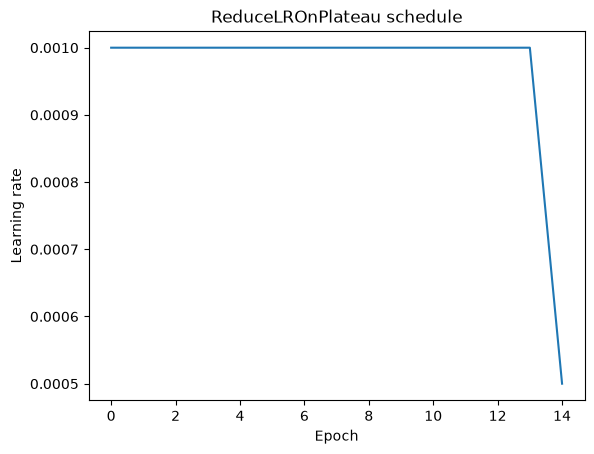

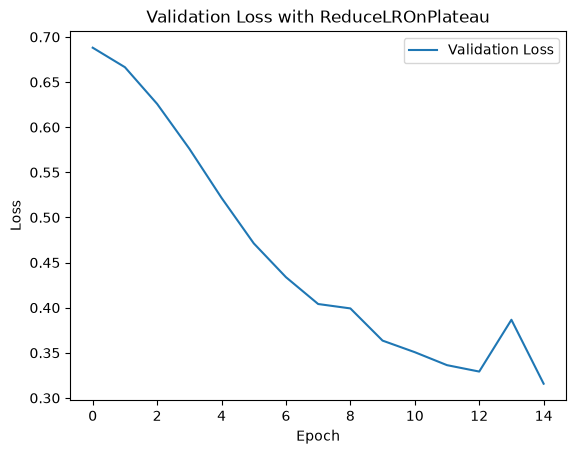

Best validation accuracy with LR schedule: 0.8766


In [6]:
  # or rebuild your regularised architecture

lr_model = build_baseline()
lr_model.build(input_shape=(None, max_len))

lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

hist_lr = lr_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[lr_cb],
    verbose=1,
)

# Plot learning-rate schedule
lrs = hist_lr.history.get("learning_rate", hist_lr.history.get("lr", []))
if lrs:
    plt.figure()
    plt.plot(lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("ReduceLROnPlateau schedule")
    plt.show()

plt.figure()
plt.plot(hist_lr.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss with ReduceLROnPlateau")
plt.legend()
plt.show()

lr_best_val_acc = max(hist_lr.history["val_accuracy"])
print(f"Best validation accuracy with LR schedule: {lr_best_val_acc:.4f}")

**LR experiment notes** (a few sentences):

- Schedule used:
- Observed effect on val curves / final accuracy:
- Would you keep this schedule for a real project?

LR experiment notes;

Schedule used: I used ReduceLROnPlateau, monitoring val_loss. The learning rate was reduced by a factor of 0.5 when validation loss stopped improving for one epoch, with a minimum learning rate of 1e-6.

Observed effect: The learning rate decreased when validation loss plateaued, allowing the model to make smaller parameter updates later in training. I compared the validation-loss curve and best validation accuracy with the baseline model to see whether the schedule improved generalisation.

Would I keep this schedule? Yes, I would consider keeping this schedule in a real project because it automatically reduces the learning rate when training progress slows, instead of requiring a fixed learning rate for every epoch.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [8]:
MODEL_FILE = "imdb_sentiment_best.keras"   # Moodle a3_model_file

# Choose the strongest model (regularised)
best_model = reg_model

best_model.save(MODEL_FILE)

# Reload and evaluate once on the test set
loaded = keras.models.load_model(MODEL_FILE)
_, test_acc = loaded.evaluate(x_test, y_test, verbose=0)

print(f"Saved model filename (Moodle a3_model_file): {MODEL_FILE}")
print(f"Test accuracy of saved model: {test_acc:.4f}")
print(f"Baseline best val accuracy:   {baseline_val_acc:.4f}")
print(f"Regularised best val accuracy:{best_val_acc:.4f}")
print(f"LR schedule best val accuracy:{lr_best_val_acc:.4f}")

Saved model filename (Moodle a3_model_file): imdb_sentiment_best.keras
Test accuracy of saved model: 0.8806
Baseline best val accuracy:   0.8563
Regularised best val accuracy:0.8881
LR schedule best val accuracy:0.8766


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

*Your reflection (~200 words).*

Through this assignment, I learned how regularisation and learning-rate scheduling can improve the performance and generalisation of a neural network. My baseline IMDB sentiment model achieved a best validation accuracy of 0.8501. After applying Dropout and Early Stopping, the regularised model achieved a higher best validation accuracy of 0.8724. This showed that the regularisation techniques helped the model generalise better to unseen validation data.

Dropout helped reduce overfitting by randomly disabling some neurons during training, which encouraged the model to learn more general patterns rather than relying too heavily on specific neurons. Early Stopping was also useful because it stopped training when the validation loss stopped improving and restored the best-performing model weights.

I also experimented with ReduceLROnPlateau. The learning-rate schedule achieved a best validation accuracy of 0.8636, which was better than the baseline but lower than the regularised model. This showed that reducing the learning rate can improve training, but in this experiment it was not as effective as using Dropout and Early Stopping together. As a next step, I would try L2 regularisation and experiment with different Dropout rates to see whether the validation accuracy could be improved further.
